# Final Results: Polymer Glass Transition Temperature Prediction

This notebook generates the main figures for the manuscript:
1. **Figure 1**: Ablation study (R² and RMSE for train/val/test, w/ and w/o descriptors, RMSE only, SVM reference)
2. **Figure 2**: True vs. predicted + Error vs. epistemic uncertainty (with correlation coefficients)
3. **Figure 3**: Applicability Domain analysis (simplified visualization including validation set)

Supplementary plots and tables are organized in separate sections at the end.

In [2]:
# import necessary libraries
import sys
import os
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import hjson

In [3]:
from sklearn.metrics import r2_score, root_mean_squared_error
from scipy.stats import pearsonr, spearmanr

from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import mahalanobis

from lightning import pytorch as pl
import torch

from chemprop import data, featurizers, models, nn, utils, uncertainty
from chemprop.models.utils import load_model

Setting up local imports of custom python functions

In [4]:
# Ensure project root is on path (one level up from 'development')
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [5]:
figs_dir = PROJECT_ROOT / "figs" 

models_dir = PROJECT_ROOT / "models"

In [6]:
# reducing verbosity
import logging
logging.getLogger("lightning.pytorch").setLevel(logging.ERROR)
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
logging.getLogger("torch").setLevel(logging.ERROR)
import warnings
warnings.filterwarnings("ignore")

# Prepare dataset

In [7]:
smiles_column = 'SMILES_clean' # column with SMILES notation strings
target_column = ['logTg'] # column with target variable value

# List of molecular descriptors
descriptor_list = [
    'Moleculer Weight',
    'Proxy for Free Volume',
    'Rotatable Bonds',
    'Aromatic Rings',
    'Topological Polar Surface Area',
    'H-Bond Donors',
    'H-Bond Acceptors'
]

In [8]:
# Ensemble configuration
N_ENSEMBLE = 100  # Number of models in ensemble
DATA_SPLIT_SEED = 42   # Fixed seed for train/val split (consistent with tuning)
K_FOLDS = 10

In [9]:
# Load training data (used for validation set)
df_train = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "training_data.csv")

all_smis = df_train.loc[:, smiles_column].values
all_ys = df_train.loc[:, target_column].values  # Shape: (N,)
all_descriptors = df_train.loc[:, descriptor_list].values  # Shape: (N, num_descriptors)
print(f"All data: {len(all_smis)} total samples")
print(f"All targets shape: {all_ys.shape}")
print(f"All descriptors shape: {all_descriptors.shape}")

All data: 683 total samples
All targets shape: (683, 1)
All descriptors shape: (683, 7)


In [10]:
# Load independent test data
df_test = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "test_data.csv")

test_smis = df_test.loc[:, smiles_column].values
test_ys_true = df_test.loc[:, target_column].values.flatten()
test_descriptors = df_test.loc[:, descriptor_list].values

print(f"\nTest data: {len(test_smis)} samples")
print(f"Test targets shape: {test_ys_true.shape}")
print(f"Test descriptors shape: {test_descriptors.shape}")


Test data: 219 samples
Test targets shape: (219,)
Test descriptors shape: (219, 7)


In [11]:
# create RDKit molecule objects from SMILES notation strings
all_mols = [
    utils.make_mol(smi, keep_h=False, add_h=False) for smi in all_smis
]

In [12]:
# Prepare input data
test_mols = [
    utils.make_mol(smi, keep_h=False, add_h=False) for smi in test_smis
]

In [13]:
# Load K-fold train/val split indices from metadata
with open(PROJECT_ROOT / "models" / "train_data_split_indexes.pkl", "rb") as f:
    train_idxs_dict = pickle.load(f)

with open(PROJECT_ROOT / "models" / "validation_data_split_indexes.pkl", "rb") as f:
    val_idxs_dict = pickle.load(f)

In [14]:
train_mols_kfold_dict = {}
train_ys_kfold_dict = {}
train_desc_kfold_dict = {}
val_mols_kfold_dict = {}
val_ys_kfold_dict = {}
val_desc_kfold_dict = {}
for fold_ in train_idxs_dict.keys():
    print("Fold:", fold_ + 1)
    print("Total training samples:", len(train_idxs_dict[fold_]))
    print("Total validation samples:", len(val_idxs_dict[fold_]))
    train_mols_kfold_dict[fold_] = [all_mols[i] for i in train_idxs_dict[fold_]]
    train_ys_kfold_dict[fold_] = all_ys[train_idxs_dict[fold_]]
    train_desc_kfold_dict[fold_] = all_descriptors[train_idxs_dict[fold_]]
    val_mols_kfold_dict[fold_] = [all_mols[i] for i in val_idxs_dict[fold_]]
    val_ys_kfold_dict[fold_] = all_ys[val_idxs_dict[fold_]]
    val_desc_kfold_dict[fold_] = all_descriptors[val_idxs_dict[fold_]]

Fold: 1
Total training samples: 614
Total validation samples: 69
Fold: 2
Total training samples: 614
Total validation samples: 69
Fold: 3
Total training samples: 614
Total validation samples: 69
Fold: 4
Total training samples: 615
Total validation samples: 68
Fold: 5
Total training samples: 615
Total validation samples: 68
Fold: 6
Total training samples: 615
Total validation samples: 68
Fold: 7
Total training samples: 615
Total validation samples: 68
Fold: 8
Total training samples: 615
Total validation samples: 68
Fold: 9
Total training samples: 615
Total validation samples: 68
Fold: 10
Total training samples: 615
Total validation samples: 68


# Ensemble Prediction & Uncertainty Quantification
Compute mean prediction, epistemic (model) and aleatoric (data) uncertainty for each ensemble.

In [15]:
# featurizer to transforms molecules into molecular graphs where atoms become nodes and bonds become edges
featurizer = featurizers.SimpleMoleculeMolGraphFeaturizer()

## Load Pre-trained Ensemble Models

In [16]:
# Load WITH descriptors ensemble
print("Loading WITH descriptors ensemble...")

with_desc_dir = models_dir / "ensemble_with_descriptors"

models_with_desc = {}

for fold_ in train_idxs_dict.keys():
    models_with_desc[fold_] = []
    # Find all best_model.ckpt files in the k-fold/seed structure
    model_ckpt_paths = sorted(with_desc_dir.glob(f"fold_{fold_+1}/seed_*/best_model.ckpt"))

    for ckpt_path in tqdm(model_ckpt_paths, desc=f"Loading WITH descriptors fold {fold_}"):
        model = load_model(ckpt_path)
        models_with_desc[fold_].append(model)

print(f"Loaded {sum(len(models) for models in models_with_desc.values())} models WITH descriptors")

Loading WITH descriptors ensemble...


Loading WITH descriptors fold 9: 100%|██████████| 100/100 [00:00<00:00, 123.77it/s]

Loaded 1000 models WITH descriptors


In [17]:
# Load WITH descriptors ensemble
print("Loading WITHOUT descriptors ensemble...")

no_desc_dir = models_dir / "ensemble_without_descriptors"

models_without_desc = {}

for fold_ in train_idxs_dict.keys():
    models_without_desc[fold_] = []
    # Find all best_model.ckpt files in the k-fold/seed structure
    model_ckpt_paths = sorted(no_desc_dir.glob(f"fold_{fold_+1}/seed_*/best_model.ckpt"))

    for ckpt_path in tqdm(model_ckpt_paths, desc=f"Loading WITHOUT descriptors fold {fold_}"):
        model = load_model(ckpt_path)
        models_without_desc[fold_].append(model)

print(f"Loaded {sum(len(models) for models in models_without_desc.values())} models WITHOUT descriptors")

Loading WITHOUT descriptors ensemble...


Loading WITHOUT descriptors fold 9: 100%|██████████| 100/100 [00:00<00:00, 123.43it/s]

Loaded 1000 models WITHOUT descriptors


## Ensemble Prediction

In [18]:
def predict_ensemble(
    models,
    featurizer,
    train_mols,
    train_ys,
    test_mols,
    test_ys,
    train_descriptors=None,
    test_descriptors=None
):
    """
    Make predictions with an ensemble of models (flat list).
    
    Returns:
        preds_mean: mean prediction across ensemble
        preds_std: standard deviation across ensemble
        all_preds: individual predictions (N_models × N_samples)
    """
    if train_descriptors is not None:
        # MoleculeDatapoints are made from target value(s) SMILES and additional descriptors.
        train_data_w_desc = [
            data.MoleculeDatapoint(train_mols[i], train_ys[i], x_d=train_descriptors[i]) for i in range(len(train_mols))
        ]
        # define training dataset of molecules and it's features
        train_dset_w_desc = data.MoleculeDataset(train_data_w_desc, featurizer)
    
        # normalizing molecular descriptor data provided as additional features
        descriptors_scaler = train_dset_w_desc.normalize_inputs("X_d")

    
        test_data_w_desc = [
            data.MoleculeDatapoint(test_mols[i], test_ys[i], x_d=test_descriptors[i]) for i in range(len(test_mols))
        ]

        # define validation dataset
        test_dset_w_desc = data.MoleculeDataset(test_data_w_desc, featurizer)

        test_dset_w_desc.normalize_inputs("X_d", descriptors_scaler)

        # Create data loader
        test_desc_data_loader = data.build_dataloader(
            test_dset_w_desc,
            batch_size=len(test_dset_w_desc),
            num_workers=0,
            shuffle=False
        )
    else:
        # MoleculeDatapoints are made from target value(s) SMILES and additional descriptors.
        train_data_w_desc = [
            data.MoleculeDatapoint(train_mols[i], train_ys[i]) for i in range(len(train_mols))
        ]
        # define training dataset of molecules and it's features
        train_dset_w_desc = data.MoleculeDataset(train_data_w_desc, featurizer)
    
        test_data_w_desc = [
            data.MoleculeDatapoint(test_mols[i], test_ys[i]) for i in range(len(test_mols))
        ]

        # define validation dataset
        test_dset_w_desc = data.MoleculeDataset(test_data_w_desc, featurizer)

    # Create data loader
    test_desc_data_loader = data.build_dataloader(
        test_dset_w_desc,
        batch_size=len(test_dset_w_desc),
        num_workers=0,
        shuffle=False
    )
    
    # Set up PyTorch Lightning trainer for predictions (suppress output)
    trainer = pl.Trainer(
        accelerator='auto',
        devices=1,
        logger=False,
        enable_checkpointing=False,
        enable_progress_bar=False,
        enable_model_summary=False
    )
    
    # Initialize list to save all predicted values
    all_preds = []
    for model in models:
        model.eval()
        pred = trainer.predict(model, test_desc_data_loader)
        preds = torch.cat(pred).cpu().numpy().flatten()
        all_preds.append(preds)
    
    all_preds = np.stack(all_preds, axis=0)  # Shape: (N_models, N_samples)
    
    return all_preds

In [19]:
# predict training sets with models WITH descriptors
train_preds_with_desc = {}
for fold_ in train_idxs_dict.keys():
    train_preds_with_desc[fold_] = predict_ensemble(
        models=models_with_desc[fold_],
        featurizer=featurizer,
        train_mols=train_mols_kfold_dict[fold_],
        train_ys=train_ys_kfold_dict[fold_],
        train_descriptors=train_desc_kfold_dict[fold_],
        test_mols=train_mols_kfold_dict[fold_],
        test_ys=train_ys_kfold_dict[fold_],
        test_descriptors=train_desc_kfold_dict[fold_]
    )

In [20]:
# predict training sets with models WITHOUT descriptors
train_preds_no_desc = {}
for fold_ in train_idxs_dict.keys():
    train_preds_no_desc[fold_] = predict_ensemble(
        models=models_without_desc[fold_],
        featurizer=featurizer,
        train_mols=train_mols_kfold_dict[fold_],
        train_ys=train_ys_kfold_dict[fold_],
        test_mols=train_mols_kfold_dict[fold_],
        test_ys=train_ys_kfold_dict[fold_]
    )

In [21]:
# predict validation sets with models WITHOUT descriptors
val_preds_no_desc = {}
for fold_ in train_idxs_dict.keys():
    val_preds_no_desc[fold_] = predict_ensemble(
        models=models_without_desc[fold_],
        featurizer=featurizer,
        train_mols=train_mols_kfold_dict[fold_],
        train_ys=train_ys_kfold_dict[fold_],
        test_mols=val_mols_kfold_dict[fold_],
        test_ys=val_ys_kfold_dict[fold_]
    )

In [22]:
# predict validation sets with models WITH descriptors
val_preds_with_desc = {}
for fold_ in train_idxs_dict.keys():
    val_preds_with_desc[fold_] = predict_ensemble(
        models=models_with_desc[fold_],
        featurizer=featurizer,
        train_mols=train_mols_kfold_dict[fold_],
        train_ys=train_ys_kfold_dict[fold_],
        train_descriptors=train_desc_kfold_dict[fold_],
        test_mols=val_mols_kfold_dict[fold_],
        test_ys=val_ys_kfold_dict[fold_],
        test_descriptors=val_desc_kfold_dict[fold_]
    )

In [23]:
# predict test sets with models WITHOUT descriptors
test_preds_no_desc = {}
for fold_ in train_idxs_dict.keys():
    test_preds_no_desc[fold_] = predict_ensemble(
        models=models_without_desc[fold_],
        featurizer=featurizer,
        train_mols=train_mols_kfold_dict[fold_],
        train_ys=train_ys_kfold_dict[fold_],
        test_mols=test_mols,
        test_ys=test_ys_true
    )

In [24]:
# predict test sets with models WITHOUT descriptors
test_preds_with_desc = {}
for fold_ in train_idxs_dict.keys():
    test_preds_with_desc[fold_] = predict_ensemble(
        models=models_with_desc[fold_],
        featurizer=featurizer,
        train_mols=train_mols_kfold_dict[fold_],
        train_ys=train_ys_kfold_dict[fold_],
        train_descriptors=train_desc_kfold_dict[fold_],
        test_mols=test_mols,
        test_ys=test_ys_true,
        test_descriptors=test_descriptors
    )

# Figure 1: Ablation Study - Performance Comparison

This section creates the ablation plot showing R² and RMSE for training, validation, and test datasets.
- **Models compared**: D-MPNN with descriptors, D-MPNN without descriptors (RMSE loss only)
- **Reference**: SVM with MinMaxScaling shown as dashed line for training and test sets only
- **Metrics**: R² and RMSE
- **Datasets**: Training, Validation, Test

Note: MSE loss results are shown in Supplementary Material.

In [25]:
# read HJSON
with open(PROJECT_ROOT / 'data' / 'processed' / 'svm_models' / 'svm_model_results.hjson', 'r') as f:
    svm_metrics_hjson = hjson.load(f)

In [26]:
svm_metrics_hjson

OrderedDict([('Training_StandardScaling',
              OrderedDict([('r2_score', 0.9898202430699362),
                           ('rmse', 0.014425543862993122)])),
             ('Training_MinMaxScaling',
              OrderedDict([('r2_score', 0.8173543738301379),
                           ('rmse', 0.06110378738367292)])),
             ('Testing_MinMaxScaling',
              OrderedDict([('r2_score', 0.6587294038467015),
                           ('rmse', 0.08113862907453091)])),
             ('Testing_StandardScaling',
              OrderedDict([('r2_score', 0.7320528401813939),
                           ('rmse', 0.0718956822010479)]))])

In [27]:
# Extract SVM StandardScaling baseline values (for training and test only)
svm_train_r2 = svm_metrics_hjson['Training_StandardScaling']['r2_score']
svm_train_rmse = svm_metrics_hjson['Training_StandardScaling']['rmse']
svm_test_r2 = svm_metrics_hjson['Testing_StandardScaling']['r2_score']
svm_test_rmse = svm_metrics_hjson['Testing_StandardScaling']['rmse']

In [28]:
# mean prediction for test set with descriptors
test_preds_with_desc_mean = np.concatenate(
    [test_preds_with_desc[k] for k in test_preds_with_desc]
).mean(axis=0)
# mean prediction for test set without descriptors
test_preds_no_desc_mean = np.concatenate(
    [test_preds_no_desc[k] for k in test_preds_no_desc]
).mean(axis=0)

In [29]:
from collections import defaultdict
train_preds_by_sample_idx_with_desc = defaultdict(list)
train_preds_by_sample_idx_no_desc = defaultdict(list)
train_ys_by_sample_idx = {}

# Collect predictions for each sample across all folds
for fold_ in train_idxs_dict.keys():
    train_indices = train_idxs_dict[fold_]  # Indices of samples in training for this fold
    train_preds_fold_no_desc_mean = train_preds_no_desc[fold_].mean(axis=0)  # Mean prediction across ensemble
    train_preds_fold_with_desc_mean = train_preds_with_desc[fold_].mean(axis=0)  # Mean prediction across ensemble
    for idx, pred_no_desc, pred_with_desc in zip(
        train_indices,
        train_preds_fold_no_desc_mean,
        train_preds_fold_with_desc_mean
    ):
        train_preds_by_sample_idx_no_desc[idx].append(pred_no_desc)
        train_preds_by_sample_idx_with_desc[idx].append(pred_with_desc)
        # Store true value (same for all folds, so just overwrite)
        train_ys_by_sample_idx[idx] = all_ys[idx].flatten()[0]

In [30]:
# Average predictions for each sample
train_sample_indices = sorted(train_preds_by_sample_idx_no_desc.keys())
train_ys_averaged = np.array([train_ys_by_sample_idx[idx] for idx in train_sample_indices])
train_preds_averaged_no_desc = np.array([np.mean(train_preds_by_sample_idx_no_desc[idx]) for idx in train_sample_indices])
train_preds_averaged_with_desc = np.array([np.mean(train_preds_by_sample_idx_with_desc[idx]) for idx in train_sample_indices])

print(f"Training samples (averaged across folds): {len(train_ys_averaged)}")
print(f"Expected: {len(all_ys)} (all samples appear in training)")

Training samples (averaged across folds): 683
Expected: 683 (all samples appear in training)


In [31]:
# r2 and rmse for training, validation and test sets
r2_val_with_desc = []
rmse_val_with_desc = []
r2_val_no_desc = []
rmse_val_no_desc = []

for fold_ in train_idxs_dict.keys():
    # with descriptors
    ## validation R2
    r2_val_with_desc.append(
        r2_score(val_ys_kfold_dict[fold_], val_preds_with_desc[fold_].mean(axis=0))
    )
    ## validation RMSE
    rmse_val_with_desc.append(
        root_mean_squared_error(val_ys_kfold_dict[fold_], val_preds_with_desc[fold_].mean(axis=0))
    )
    # without descriptors
    ## validation R2
    r2_val_no_desc.append(
        r2_score(val_ys_kfold_dict[fold_], val_preds_no_desc[fold_].mean(axis=0))
    )
    ## validation RMSE
    rmse_val_no_desc.append(
        root_mean_squared_error(val_ys_kfold_dict[fold_], val_preds_no_desc[fold_].mean(axis=0))
    )

In [32]:
r2_train_with_desc = r2_score(train_ys_averaged, train_preds_averaged_with_desc)
rmse_train_with_desc = root_mean_squared_error(train_ys_averaged, train_preds_averaged_with_desc)

r2_train_no_desc = r2_score(train_ys_averaged, train_preds_averaged_no_desc)
rmse_train_no_desc = root_mean_squared_error(train_ys_averaged, train_preds_averaged_no_desc)

In [33]:
r2_val_mean_with_desc = np.mean(np.array(r2_val_with_desc))
rmse_val_mean_with_desc = np.mean(np.array(rmse_val_with_desc))

r2_val_mean_no_desc = np.mean(np.array(r2_val_no_desc))
rmse_val_mean_no_desc = np.mean(np.array(rmse_val_no_desc))

In [34]:
r2_test_with_desc = r2_score(test_ys_true, test_preds_with_desc_mean)
rmse_test_with_desc = root_mean_squared_error(test_ys_true, test_preds_with_desc_mean)

r2_test_no_desc = r2_score(test_ys_true, test_preds_no_desc_mean)
rmse_test_no_desc = root_mean_squared_error(test_ys_true, test_preds_no_desc_mean)

In [35]:
print("R2-score and RMSE for training, validation and test sets:")

print("With descriptors:")
print(f"Training: R2-score={r2_train_with_desc:.3f}, RMSE={rmse_train_with_desc:.4f}")
print(f"Validation: R2-score={r2_val_mean_with_desc:.3f}, RMSE={rmse_val_mean_with_desc:.4f}")
print(f"Test: R2-score={r2_test_with_desc:.3f}, RMSE={rmse_test_with_desc:.4f}")

print("Without descriptors:")
print(f"Training: R2-score={r2_train_no_desc:.4f}, RMSE={rmse_train_no_desc:.4f}")
print(f"Validation: R2-score={r2_val_mean_no_desc:.4f}, RMSE={rmse_val_mean_no_desc:.4f}")
print(f"Test: R2-score={r2_test_no_desc:.3f}, RMSE={rmse_test_no_desc:.4f}")

R2-score and RMSE for training, validation and test sets:
With descriptors:
Training: R2-score=0.881, RMSE=0.0494
Validation: R2-score=0.879, RMSE=0.0479
Test: R2-score=0.747, RMSE=0.0698
Without descriptors:
Training: R2-score=0.9105, RMSE=0.0428
Validation: R2-score=0.9108, RMSE=0.0410
Test: R2-score=0.765, RMSE=0.0673


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


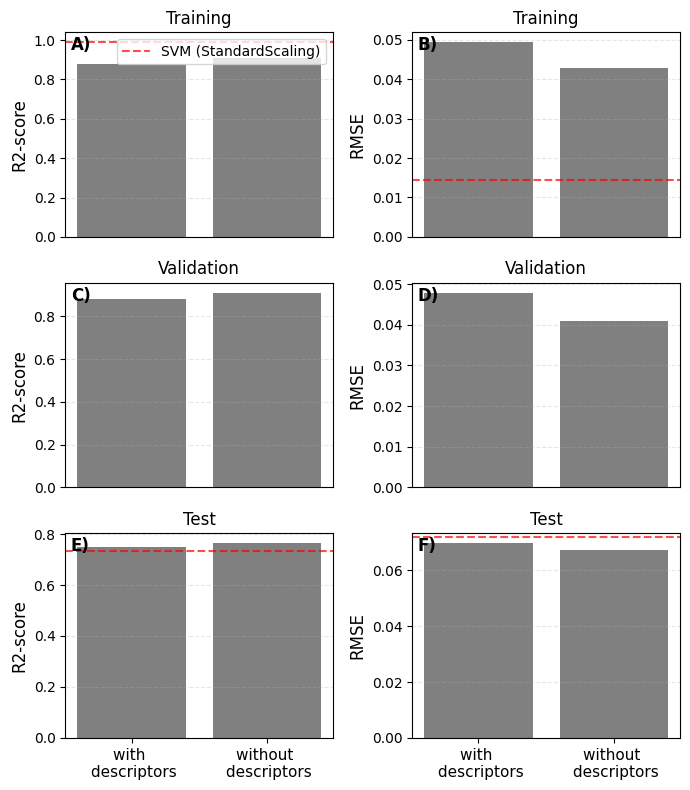

In [36]:
# Create 3x2 plot for ablation study (rotated: 3 rows × 2 columns)
fig, ax = plt.subplots(3, 2, figsize=(7, 8))

# Prepare data
plot_configs = [
    # Column 0: R² scores
    {'row': 0, 'col': 0, 'data': [r2_train_with_desc, r2_train_no_desc], 
     'title': 'Training', 'svm_baseline': svm_train_r2, 'ylabel': 'R2-score'},
    {'row': 1, 'col': 0, 'data': [r2_val_mean_with_desc, r2_val_mean_no_desc], 
     'title': 'Validation', 'svm_baseline': None, 'ylabel': 'R2-score'},
    {'row': 2, 'col': 0, 'data': [r2_test_with_desc, r2_test_no_desc], 
     'title': 'Test', 'svm_baseline': svm_test_r2, 'ylabel': 'R2-score'},
    # Column 1: RMSE
    {'row': 0, 'col': 1, 'data': [rmse_train_with_desc, rmse_train_no_desc], 
     'title': 'Training', 'svm_baseline': svm_train_rmse, 'ylabel': 'RMSE'},
    {'row': 1, 'col': 1, 'data': [rmse_val_mean_with_desc, rmse_val_mean_no_desc], 
     'title': 'Validation', 'svm_baseline': None, 'ylabel': 'RMSE'},
    {'row': 2, 'col': 1, 'data': [rmse_test_with_desc, rmse_test_no_desc], 
     'title': 'Test', 'svm_baseline': svm_test_rmse, 'ylabel': 'RMSE'},
]

model_labels = ['with \n descriptors', 'without \n descriptors']
x_pos = np.arange(len(model_labels))

for config in plot_configs:
    row, col = config['row'], config['col']
    
    # Create vertical bar plot with smaller width for less gap
    bars = ax[row, col].bar(
        x=x_pos,
        height=config['data'],
        width=0.8,  # Increased width for less gap between bars
        color='gray'  # All gray
    )
    
    # Add SVM baseline line for training and test only
    if config['svm_baseline'] is not None:
        ax[row, col].axhline(
            config['svm_baseline'],
            color='red',
            linestyle='--',
            linewidth=1.5,
            label='SVM (StandardScaling)',
            alpha=0.7
        )
    
    ax[row, col].set_ylabel(config['ylabel'], fontsize=12)  # Removed bold
    ax[row, col].set_title(config['title'], fontsize=12)  # Removed bold
    
    # Set x-axis labels - horizontal, only on bottom row
    if row == 2:  # Bottom row shows model labels
        ax[row, col].set_xticks(x_pos)
        ax[row, col].set_xticklabels(model_labels, fontsize=11, rotation=0, ha='center')
    else:
        ax[row, col].set_xticks([])
    
    ax[row, col].tick_params(axis='y', labelsize=10)
    ax[row, col].grid(axis='y', linestyle='--', alpha=0.3)
    
    # Add legend only to first plot with SVM baseline (top-left)
    if config['svm_baseline'] is not None and row == 0 and col == 0:
        ax[row, col].legend(fontsize=10, loc='upper right')

# Add panel labels (A, B, C, D, E, F)
labels = ['A)', 'B)', 'C)', 'D)', 'E)', 'F)']
for idx, ax_ in enumerate(ax.flat):
    ax_.text(0.02, 0.98, labels[idx],
            transform=ax_.transAxes, fontsize=12,
            va='top', ha='left', fontweight='bold')

plt.tight_layout()
plt.savefig(
    figs_dir / 'performance_metrics_ablation_barplots.eps',
    format='eps',
    bbox_inches='tight',
)
plt.show()

## Removing bad data-points within test data-set

In [37]:
bad_data_points = [
    'ethylene', # also present in training set with different target value
    'vinylchloroacetate' # incorrect smiles notation    
]

In [38]:
test_ys_true[
    df_test['name'].isin(bad_data_points)
]

array([2.1703, 2.4829])

In [39]:
test_preds_with_desc_mean[
    df_test['name'].isin(bad_data_points)
]

array([2.2868173, 2.6137328], dtype=float32)

In [40]:
test_preds_no_desc_mean[
    df_test['name'].isin(bad_data_points)
]

array([2.281854 , 2.6345594], dtype=float32)

In [41]:
test_ys_true_cleaned = test_ys_true[
    ~df_test['name'].isin(bad_data_points)
]
test_preds_no_desc_mean_cleaned = test_preds_no_desc_mean[
    ~df_test['name'].isin(bad_data_points)
]
test_preds_with_desc_mean_cleaned = test_preds_with_desc_mean[
    ~df_test['name'].isin(bad_data_points)
]

In [42]:
r2_test_with_desc_cleaned = r2_score(test_ys_true_cleaned, test_preds_with_desc_mean_cleaned)
rmse_test_with_desc_cleaned = root_mean_squared_error(test_ys_true_cleaned, test_preds_with_desc_mean_cleaned)

r2_test_no_desc_cleaned = r2_score(test_ys_true_cleaned, test_preds_no_desc_mean_cleaned)
rmse_test_no_desc_cleaned = root_mean_squared_error(test_ys_true_cleaned, test_preds_no_desc_mean_cleaned)

In [43]:
print("R2-score and RMSE for cleaned test sets:")

print("With descriptors:")
print(f"Test: R2-score={r2_test_with_desc_cleaned:.3f}, RMSE={rmse_test_with_desc_cleaned:.4f}")

print("Without descriptors:")
print(f"Test: R2-score={r2_test_no_desc_cleaned:.3f}, RMSE={rmse_test_no_desc_cleaned:.4f}")

R2-score and RMSE for cleaned test sets:
With descriptors:
Test: R2-score=0.746, RMSE=0.0691
Without descriptors:
Test: R2-score=0.765, RMSE=0.0664


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


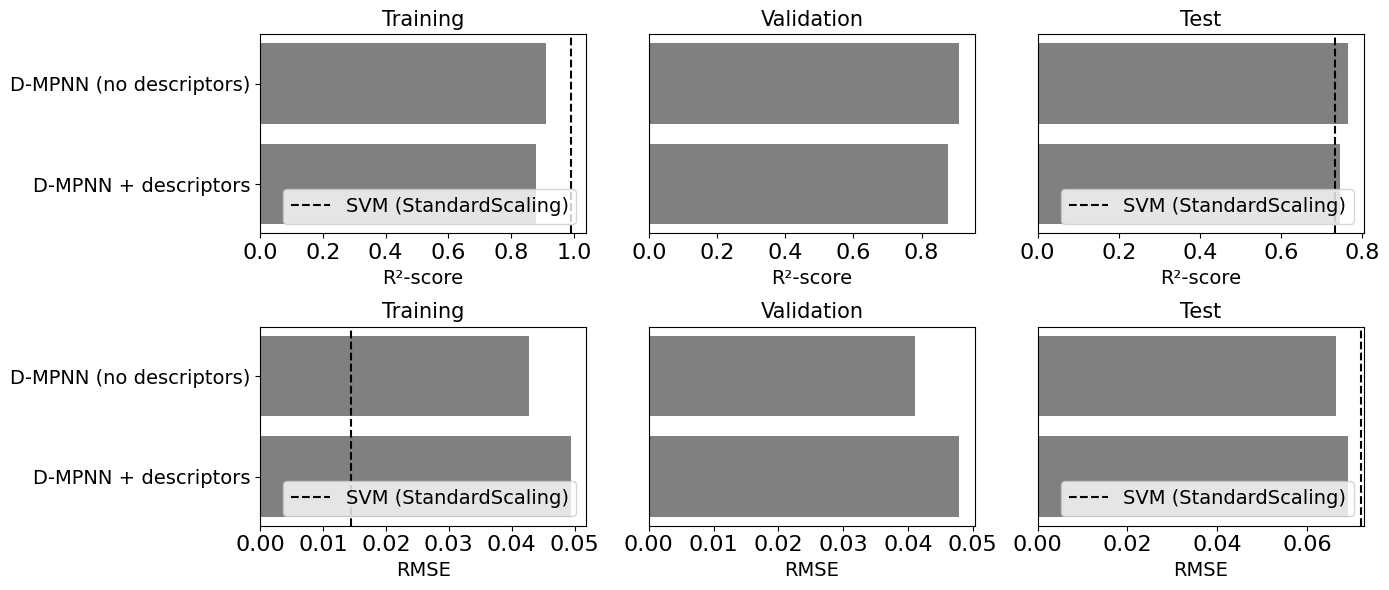

In [44]:
plt.figure(figsize=(14, 6))  # Adjusted height for 2 rows
for i in range(2):  # 2 rows: R² and RMSE
    for j in range(3):  # 3 columns: Training, Validation, Test
        if i == 0 and j == 0:
            x_data = [r2_train_with_desc, r2_train_no_desc]
            title_ = 'Training'
            svm_baseline = svm_train_r2
        elif i == 0 and j == 1:
            x_data = [r2_val_mean_with_desc, r2_val_mean_no_desc]
            title_ = 'Validation'
            svm_baseline = None  # No SVM baseline for validation
        elif i == 0 and j == 2:
            x_data = [r2_test_with_desc_cleaned, r2_test_no_desc_cleaned]
            title_ = 'Test'
            svm_baseline = svm_test_r2
        elif i == 1 and j == 0:
            x_data = [rmse_train_with_desc, rmse_train_no_desc]
            title_ = 'Training'
            svm_baseline = svm_train_rmse
        elif i == 1 and j == 1:
            x_data = [rmse_val_mean_with_desc, rmse_val_mean_no_desc]
            title_ = 'Validation'
            svm_baseline = None  # No SVM baseline for validation
        elif i == 1 and j == 2:
            x_data = [rmse_test_with_desc_cleaned, rmse_test_no_desc_cleaned]
            title_ = 'Test'
            svm_baseline = svm_test_rmse

        if i == 0:
            ylabel_ = 'R²-score'
        elif i == 1:
            ylabel_ = 'RMSE'
            
        plt.subplot(2, 3, i*3 + j + 1)  # Fixed: 2 rows × 3 columns indexing
        plt.barh(
            y=['D-MPNN + descriptors', 'D-MPNN (no descriptors)'],
            width=x_data,
            color='gray'
        )
        
        # Add SVM baseline line for training and test only (not validation)
        if svm_baseline is not None:
            plt.axvline(
                svm_baseline,
                color='k',
                linestyle='--',
                linewidth=1.5, 
                label='SVM (StandardScaling)',
            )
        
        plt.xlabel(ylabel_, fontsize=14)
        plt.title(title_, fontsize=15)
        
        # Only show y-axis labels on the leftmost column (j == 0)
        if j != 0:
            plt.yticks([])
        else:
            plt.yticks(fontsize=14)
        
        plt.xticks(fontsize=16)
        
        # Add legend only for plots with SVM baseline (training and test)
        if svm_baseline is not None and j % 2 == 0:  # Add legend only to first plot with baseline
            plt.legend(fontsize=14, loc='lower right')
plt.tight_layout()  # Added to prevent overlapping

plt.savefig(
    figs_dir / 'performance_metrics_ablation_barplots_fixed.eps',
    format='eps',
    bbox_inches='tight'
)            
plt.show()

# True vs. Predicted + Error vs. Epistemic Uncertainty

This section creates the true vs. predicted scatter plots and absolute error vs. epistemic uncertainty plots for the best model configuration (D-MPNN with descriptors, RMSE loss).

**Plots:**
- **Top row**: True vs. predicted values (training and test)
- **Bottom row**: Absolute relative error vs. epistemic uncertainty (training and test)

**Correlation coefficients** are computed and displayed for absolute error vs. epistemic uncertainty relationships.

In [45]:
# 2 X 3 plots 
# top 3 will be true vs predicted from w/o descriptors for training, validation and test
# bottom 3 will be absolute relative error vs epistemic uncertainty from w/o descriptors for training, validation and test

# Compute epistemic uncertainty for each fold
# Epistemic uncertainty = std dev across ensemble predictions (axis=0 = across models)

In [46]:
# Also average epistemic uncertainties for training samples
train_unc_by_sample_idx_no_desc = defaultdict(list)
train_unc_by_sample_idx_with_desc = defaultdict(list)

for fold_ in train_idxs_dict.keys():
    train_indices = train_idxs_dict[fold_]
    train_unc_fold_no_desc = np.std(train_preds_no_desc[fold_], axis=0)  # Epistemic uncertainty
    train_unc_fold_with_desc = np.std(train_preds_with_desc[fold_], axis=0)  # Epistemic uncertainty
    
    for idx, unc_no_desc, unc_with_desc in zip(train_indices, train_unc_fold_no_desc, train_unc_fold_with_desc):
        train_unc_by_sample_idx_no_desc[idx].append(unc_no_desc)
        train_unc_by_sample_idx_with_desc[idx].append(unc_with_desc)

# Average uncertainties for each sample
train_unc_averaged_no_desc = np.array([np.mean(train_unc_by_sample_idx_no_desc[idx]) for idx in train_sample_indices])
train_unc_averaged_with_desc = np.array([np.mean(train_unc_by_sample_idx_with_desc[idx]) for idx in train_sample_indices])

# Update the variables for use in plots (for no descriptors version)
train_all_ys_concat = train_ys_averaged
train_all_preds_concat = train_preds_averaged_no_desc
train_all_unc_concat = train_unc_averaged_no_desc

In [47]:
epistemic_unc_train_no_desc_per_fold = {}
epistemic_unc_val_no_desc_per_fold = {}
epistemic_unc_test_no_desc_per_fold = {}

for fold_ in train_idxs_dict.keys():
    # Training: std dev across models gives uncertainty per sample
    epistemic_unc_train_no_desc_per_fold[fold_] = np.std(train_preds_no_desc[fold_], axis=0)
    
    # Validation: std dev across models
    epistemic_unc_val_no_desc_per_fold[fold_] = np.std(val_preds_no_desc[fold_], axis=0)
    
    # Test: std dev across models (same test set for all folds)
    epistemic_unc_test_no_desc_per_fold[fold_] = np.std(test_preds_no_desc[fold_], axis=0)

In [48]:
# CONCATENATE for training and validation (different samples per fold)
train_all_ys_concat = np.concatenate(
    [train_ys_kfold_dict[k].flatten() for k in train_ys_kfold_dict.keys()]
)
train_all_preds_concat = np.concatenate(
    [train_preds_no_desc[k].mean(axis=0) for k in train_preds_no_desc.keys()]
)
train_all_unc_concat = np.concatenate(
    [epistemic_unc_train_no_desc_per_fold[k] for k in epistemic_unc_train_no_desc_per_fold.keys()]
)

val_all_ys_concat = np.concatenate(
    [val_ys_kfold_dict[k].flatten() for k in val_ys_kfold_dict.keys()]
)
val_all_preds_concat = np.concatenate(
    [val_preds_no_desc[k].mean(axis=0) for k in val_preds_no_desc.keys()]
)
val_all_unc_concat = np.concatenate(
    [epistemic_unc_val_no_desc_per_fold[k] for k in epistemic_unc_val_no_desc_per_fold.keys()]
)

# AVERAGE for test (same test set across all folds)
test_all_unc_mean = np.mean(
    [epistemic_unc_test_no_desc_per_fold[k] for k in epistemic_unc_test_no_desc_per_fold.keys()],
    axis=0
)

In [49]:
# Compute absolute relative error
rel_error_train = np.abs(train_all_ys_concat - train_all_preds_concat) / train_all_ys_concat
rel_error_val = np.abs(val_all_ys_concat - val_all_preds_concat) / val_all_ys_concat
rel_error_test = np.abs(test_ys_true - test_preds_no_desc_mean) / test_ys_true

In [50]:
# Compute correlation coefficients between absolute relative error and epistemic uncertainty

# Pearson and Spearman correlations for training set
pearson_train, pearson_p_train = pearsonr(train_all_unc_concat, rel_error_train)
spearman_train, spearman_p_train = spearmanr(train_all_unc_concat, rel_error_train)

# Pearson and Spearman correlations for validation set
pearson_val, pearson_p_val = pearsonr(val_all_unc_concat, rel_error_val)
spearman_val, spearman_p_val = spearmanr(val_all_unc_concat, rel_error_val)

# Pearson and Spearman correlations for test set
pearson_test, pearson_p_test = pearsonr(test_all_unc_mean, rel_error_test)
spearman_test, spearman_p_test = spearmanr(test_all_unc_mean, rel_error_test)

In [51]:
# Print correlation results
print("=== Correlation Analysis: Absolute Relative Error vs. Epistemic Uncertainty ===")
print(f"Training - Pearson r = {pearson_train:.4f} (p = {pearson_p_train:.2e})")
print(f"Training - Spearman ρ = {spearman_train:.4f} (p = {spearman_p_train:.2e})")
print(f"Validation - Pearson r = {pearson_val:.4f} (p = {pearson_p_val:.2e})")
print(f"Validation - Spearman ρ = {spearman_val:.4f} (p = {spearman_p_val:.2e})")
print(f"Test - Pearson r = {pearson_test:.4f} (p = {pearson_p_test:.2e})")
print(f"Test - Spearman ρ = {spearman_test:.4f} (p = {spearman_p_test:.2e})")

=== Correlation Analysis: Absolute Relative Error vs. Epistemic Uncertainty ===
Training - Pearson r = 0.2756 (p = 1.46e-107)
Training - Spearman ρ = 0.2754 (p = 2.28e-107)
Validation - Pearson r = 0.2756 (p = 2.27e-13)
Validation - Spearman ρ = 0.2754 (p = 2.38e-13)
Test - Pearson r = 0.4042 (p = 5.14e-10)
Test - Spearman ρ = 0.3223 (p = 1.10e-06)


In [52]:
outlier_threshold_unc_test = np.mean(test_all_unc_mean) + 3*np.std(test_all_unc_mean)
print("Epistemic Uncertainty")
print("Mean + 3*Std. dev. (testing):", outlier_threshold_unc_test)
print("Outlier threshold (testing): {0:.4f}".format(round(outlier_threshold_unc_test*10000)/10000))

outlier_threshold_err_test = np.mean(rel_error_test) + 3*np.std(rel_error_test)
print("Absolute Relative Error")
print("Mean + 3*Std. dev. (testing):", outlier_threshold_err_test)
print("Outlier threshold (testing): {0:.4f}".format(round(outlier_threshold_err_test*10000)/10000))

Epistemic Uncertainty
Mean + 3*Std. dev. (testing): 0.05803415831178427
Outlier threshold (testing): 0.0580
Absolute Relative Error
Mean + 3*Std. dev. (testing): 0.07866978307667426
Outlier threshold (testing): 0.0787


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


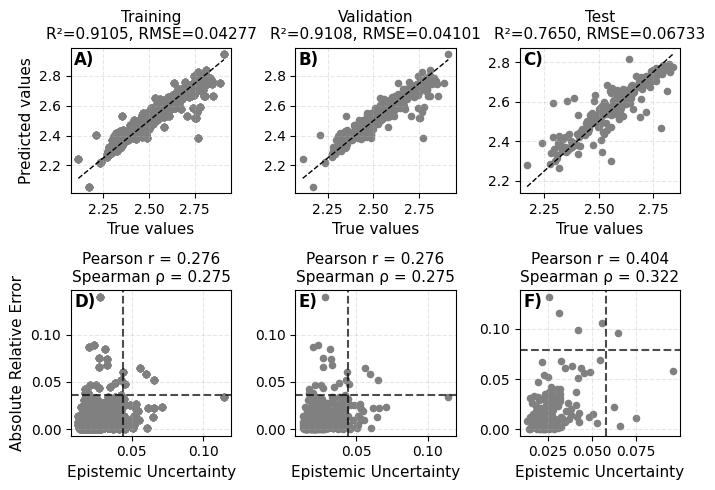

In [53]:
# Calculate outlier thresholds for training and validation sets
outlier_threshold_unc_train = np.mean(train_all_unc_concat) + 2*np.std(train_all_unc_concat)
outlier_threshold_err_train = np.mean(rel_error_train) + 2*np.std(rel_error_train)

outlier_threshold_unc_val = np.mean(val_all_unc_concat) + 2*np.std(val_all_unc_concat)
outlier_threshold_err_val = np.mean(rel_error_val) + 2*np.std(rel_error_val)

# Create 2x3 plot
fig, ax = plt.subplots(2, 3, figsize=(7, 5))

# Prepare data for plotting
plot_data = [
    {
        'y_true': train_all_ys_concat,
        'y_pred': train_all_preds_concat,
        'unc': train_all_unc_concat,
        'rel_error': rel_error_train,
        'r2': r2_train_no_desc,
        'rmse': rmse_train_no_desc,
        'title': 'Training',
        'pearson': pearson_train,
        'spearman': spearman_train,
        'ylabel': True,
        'unc_threshold': outlier_threshold_unc_train,
        'err_threshold': outlier_threshold_err_train
    },
    {
        'y_true': val_all_ys_concat,
        'y_pred': val_all_preds_concat,
        'unc': val_all_unc_concat,
        'rel_error': rel_error_val,
        'r2': r2_val_mean_no_desc,
        'rmse': rmse_val_mean_no_desc,
        'title': 'Validation',
        'pearson': pearson_val,
        'spearman': spearman_val,
        'ylabel': False,
        'unc_threshold': outlier_threshold_unc_val,
        'err_threshold': outlier_threshold_err_val
    },
    {
        'y_true': test_ys_true,
        'y_pred': test_preds_no_desc_mean,
        'unc': test_all_unc_mean,
        'rel_error': rel_error_test,
        'r2': r2_test_no_desc,
        'rmse': rmse_test_no_desc,
        'title': 'Test',
        'pearson': pearson_test,
        'spearman': spearman_test,
        'ylabel': False,
        'unc_threshold': outlier_threshold_unc_test,
        'err_threshold': outlier_threshold_err_test
    }
]

# Row 0: True vs Predicted
for i, data in enumerate(plot_data):
    ax[0, i].scatter(
        data['y_true'],
        data['y_pred'],
        color='gray',
        s=20
    )
    ax[0, i].plot(
        [data['y_true'].min(), data['y_true'].max()], 
        [data['y_true'].min(), data['y_true'].max()], 
        'k--',
        linewidth=1
    )
    ax[0, i].set_xlabel(
        'True values',
        fontsize=11
    )
    if data['ylabel']:
        ax[0, i].set_ylabel(
            'Predicted values',
            fontsize=11
        )
    ax[0, i].set_title(
        f"{data['title']}\nR²={data['r2']:.4f}, RMSE={data['rmse']:.5f}",
        fontsize=11
    )
    ax[0, i].grid(True, linestyle='--', alpha=0.3)
    ax[0, i].tick_params(axis='both', which='major', labelsize=10)

# Row 1: Absolute Relative Error vs Epistemic Uncertainty
for i, data in enumerate(plot_data):
    ax[1, i].scatter(
        data['unc'],
        data['rel_error'],
        color='gray',
        s=20
    )
    
    # Add vertical line for uncertainty threshold
    ax[1, i].axvline(
        data['unc_threshold'],
        color='k',
        linestyle='--',
        linewidth=1.5,
        alpha=0.7
    )
    
    # Add horizontal line for error threshold
    ax[1, i].axhline(
        data['err_threshold'],
        color='k',
        linestyle='--',
        linewidth=1.5,
        alpha=0.7
    )
    
    ax[1, i].set_xlabel(
        'Epistemic Uncertainty',
        fontsize=11
    )
    if data['ylabel']:
        ax[1, i].set_ylabel(
            'Absolute Relative Error',
            fontsize=11
        )
    
    ax[1, i].grid(True, linestyle='--', alpha=0.3)
    # Add correlation coefficient annotation
    ax[1, i].set_title(
        f"Pearson r = {data['pearson']:.3f}\nSpearman ρ = {data['spearman']:.3f}",
        fontsize=11
    )
    ax[1, i].tick_params(axis='both', which='major', labelsize=10)

# Add panel labels (A, B, C, D, E, F)
labels = ['A)', 'B)', 'C)', 'D)', 'E)', 'F)']
for idx, ax_ in enumerate(ax.flat):
    ax_.text(0.02, 0.98, labels[idx],
            transform=ax_.transAxes, fontsize=12,
            va='top', ha='left', fontweight='bold')

plt.tight_layout()
plt.savefig(
    figs_dir / 'Chemprop_no_features_rmse_true_vs_predicted_and_uncertainties.eps',
    format='eps',
    bbox_inches='tight'
)
plt.show()

In [54]:
Epistemic_Uncertainty_thresh = 0.0580
Absolute_Relative_Error_thresh = 0.0787

In [ ]:
(
    (test_all_unc_mean > Epistemic_Uncertainty_thresh)
    & 
    (rel_error_test > Absolute_Relative_Error_thresh)
).sum()


1

In [70]:
df_test[
    (test_all_unc_mean > Epistemic_Uncertainty_thresh)
    & 
    (rel_error_test > Absolute_Relative_Error_thresh)
][['name','SMILES']]

,name,SMILES
12,Ethylene malonate,C1COC(=O)CC(=O)O1


## Analysis: Why Ethylene Malonate Has Poor Predictions

**Ethylene malonate** (SMILES: `C1COC(=O)CC(=O)O1`) is the sole compound in the test dataset exhibiting both high epistemic uncertainty (exceeding the threshold of 0.0580) and high relative error (exceeding the threshold of 0.0787). The following analysis investigates the underlying factors contributing to this poor prediction performance.

**Key factors to investigate:**
1. Structural uniqueness: Does this compound possess distinctive structural features relative to the training dataset?
2. Descriptor distribution: Are its molecular descriptors located outside the training data distribution?
3. Applicability domain: What do multiple AD metrics reveal about its position in chemical space?
4. Structural similarity: Are analogous compounds present in the training set?

In [ ]:
(
    (test_all_unc_mean > Epistemic_Uncertainty_thresh)
    & 
    (rel_error_test < Absolute_Relative_Error_thresh)
).sum()

4

In [71]:
df_test[
    (test_all_unc_mean > Epistemic_Uncertainty_thresh)
    & 
    (rel_error_test < Absolute_Relative_Error_thresh)
][['name','SMILES']]

,name,SMILES
4,ethyl vinyl thioether,CCSC=C
6,Methyl cellulose,COCC1C(C(C(C(O1)OC2C(OC(C(C2OC)OC)OC)COC)OC)OC)OC
13,Ethylene oxide,C1CO1
15,Trimethylene oxide,C1COC1


In [69]:
df_test[(
    (test_all_unc_mean <= Epistemic_Uncertainty_thresh)
    & 
    (rel_error_test > Absolute_Relative_Error_thresh)
)][['name','SMILES']]

,name,SMILES
1,1-(tert-butyl)ethene,CC(C)(C)C=C
24,ethanol,CCO
25,ethyl a-chloroacrylate,CC(Cl)C(=O)OCC
31,propylene sulfide,CC1CS1


In [60]:
(
    (test_all_unc_mean <= Epistemic_Uncertainty_thresh)
    & 
    (rel_error_test <= Absolute_Relative_Error_thresh)
).sum()

210

In [56]:



print("Epistemic Uncertainty")
print("Mean + 3*Std. dev. (testing):", outlier_threshold_unc_test)
print("Outlier threshold (testing): {0:.4f}".format(round(outlier_threshold_unc_test*10000)/10000))

outlier_threshold_err_test = np.mean(rel_error_test

SyntaxError: incomplete input (3662839268.py, line 5)

# Correlation Analysis: AD Metrics vs Errors and Uncertainty

Analyze the relationship between applicability domain metrics and prediction quality using Pearson and Spearman correlations.

In [ ]:
# load AD metrics for test set
ad_metrics_test_df = pd.read_csv(PROJECT_ROOT / "data" / "processed"/ "applicability_domain" / "ad_metrics_test_set.csv")
print(ad_metrics_test_df.shape)
ad_metrics_test_df.head()

(219, 18)


,sample_index,SMILES,logTg,leverage,leverage_threshold,mahalanobis,mahalanobis_threshold,knn_5,knn_5_threshold,pca_t2,pca_t2_threshold,leverage_outlier,mahalanobis_outlier,knn_5_outlier,pca_t2_outlier,outlier_flag_count,consensus_outlier,high_confidence_outlier
0,0,C=CC(=O)OCC(F)(F)C(F)F,2.7178,0.563468,1.470684,9.788213,15.049567,9.543485,16.239119,1.187236,2.479366,False,False,False,False,0,False,False
1,1,C=CC(C)(C)C,2.7854,2.317857,1.470684,17.331413,15.049567,15.369430,16.239119,0.941909,2.479366,True,True,False,False,2,True,False
2,2,C=C(CC(=O)OC)C(=O)OC,2.8103,0.949886,1.470684,13.043010,15.049567,11.726808,16.239119,1.301399,2.479366,False,False,False,False,0,False,False
3,3,C=CC(=O)CC,2.6868,0.830697,1.470684,11.163796,15.049567,10.966966,16.239119,1.280411,2.479366,False,False,False,False,0,False,False
4,4,C=CSCC,2.7317,1.712569,1.470684,21.257075,15.049567,22.926713,16.239119,0.115527,2.479366,True,True,True,False,3,True,True


In [ ]:
ad_metrics_test_df.columns
# add absolute relative error and epistemic uncertainty to ad_metrics_test_df

Index(['sample_index', 'SMILES', 'logTg', 'leverage', 'leverage_threshold',
       'mahalanobis', 'mahalanobis_threshold', 'knn_5', 'knn_5_threshold',
       'pca_t2', 'pca_t2_threshold', 'leverage_outlier', 'mahalanobis_outlier',
       'knn_5_outlier', 'pca_t2_outlier', 'outlier_flag_count',
       'consensus_outlier', 'high_confidence_outlier', 'abs_rel_error',
       'epistemic_unc'],
      dtype='object')

In [ ]:
# add absolute relative error and epistemic uncertainty to ad_metrics_test_df
ad_metrics_test_df['abs_rel_error'] = rel_error_test
ad_metrics_test_df['epistemic_unc'] = test_all_unc_mean

In [ ]:
metric_columns = [
    'leverage',
    'mahalanobis',
    'knn_5',
    'pca_t2'
]

In [ ]:
# Compute correlations for each AD metric
correlation_data = {}
for metric_name in metric_columns:
    # Correlation with absolute relative error
    pearson_err, pearson_err_p = pearsonr(
        ad_metrics_test_df[metric_name],
        ad_metrics_test_df['abs_rel_error']
    )
    spearman_err, spearman_err_p = spearmanr(
        ad_metrics_test_df[metric_name],
        ad_metrics_test_df['abs_rel_error']
    )
    
    # Correlation with epistemic uncertainty
    pearson_unc, pearson_unc_p = pearsonr(
        ad_metrics_test_df[metric_name],
        ad_metrics_test_df['epistemic_unc']
    )
    spearman_unc, spearman_unc_p = spearmanr(
        ad_metrics_test_df[metric_name],
        ad_metrics_test_df['epistemic_unc']
    )
    
    correlation_data[metric_name] = {
        'pearson_err': pearson_err,
        'pearson_err_p': pearson_err_p,
        'spearman_err': spearman_err,
        'spearman_err_p': spearman_err_p,
        'pearson_unc': pearson_unc,
        'pearson_unc_p': pearson_unc_p,
        'spearman_unc': spearman_unc,
        'spearman_unc_p': spearman_unc_p
    }

In [ ]:
correlation_data

{'leverage': {'pearson_err': 0.383778735598689,
  'pearson_err_p': 4.270498144226625e-09,
  'spearman_err': 0.26511777229756095,
  'spearman_err_p': 7.119799986980428e-05,
  'pearson_unc': 0.7466378737433137,
  'pearson_unc_p': 2.776675540911169e-40,
  'spearman_unc': 0.6276756394243288,
  'spearman_unc_p': 2.1506325749753824e-25},
 'mahalanobis': {'pearson_err': 0.4210724201669408,
  'pearson_err_p': 8.010859752660195e-11,
  'spearman_err': 0.22128327332324502,
  'spearman_err_p': 0.0009775128246537988,
  'pearson_unc': 0.8068625422438268,
  'pearson_unc_p': 1.6528939959795003e-51,
  'spearman_unc': 0.6175096306024767,
  'spearman_unc_p': 2.0588099282063605e-24},
 'knn_5': {'pearson_err': 0.43898394185871215,
  'pearson_err_p': 9.901567428704834e-12,
  'spearman_err': 0.2998933471347968,
  'spearman_err_p': 6.2716125336946465e-06,
  'pearson_unc': 0.7487132798774501,
  'pearson_unc_p': 1.2903786205991441e-40,
  'spearman_unc': 0.5338439949512926,
  'spearman_unc_p': 1.5626338677336146

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


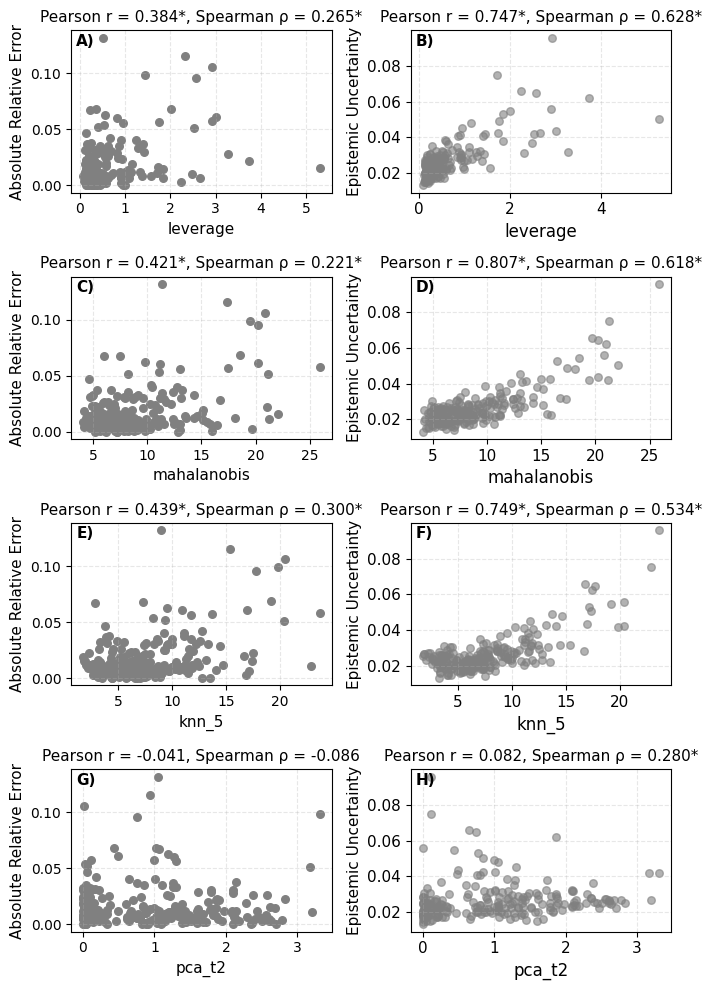

In [ ]:
# Create 4×2 visualization: 4 rows (AD metrics) × 2 columns (Error, Uncertainty)
fig, ax = plt.subplots(4, 2, figsize=(7, 10))

for i, metric_name in enumerate(metric_columns):
    corr_data = correlation_data[metric_name]
    
    # Left column: AD Metric vs Absolute Relative Error
    ax[i, 0].scatter(
        ad_metrics_test_df[metric_name],
        ad_metrics_test_df['abs_rel_error'],
        s=30,
        color='gray'
    )
    ax[i, 0].set_xlabel(metric_name, fontsize=11)
    ax[i, 0].set_ylabel('Absolute Relative Error', fontsize=11)
    
    # Add correlation to title
    title_text = f"Pearson r = {corr_data['pearson_err']:.3f}"
    if corr_data['pearson_err_p'] < 0.05:
        title_text += "*"
    title_text += f", Spearman ρ = {corr_data['spearman_err']:.3f}"
    if corr_data['spearman_err_p'] < 0.05:
        title_text += "*"
    
    if i == 0:
        ax[i, 0].set_title(title_text, fontsize=11)
    else:
        ax[i, 0].set_title(title_text, fontsize=11)
    
    ax[i, 0].grid(True, linestyle='--', alpha=0.3)
    
    # Right column: AD Metric vs Epistemic Uncertainty
    ax[i, 1].scatter(
        ad_metrics_test_df[metric_name],
        ad_metrics_test_df['epistemic_unc'],
        alpha=0.6,
        s=30,
        color='gray'
    )
    ax[i, 1].set_xlabel(metric_name, fontsize=12)
    ax[i, 1].set_ylabel('Epistemic Uncertainty', fontsize=11)
    
    # Add correlation to title
    title_text = f"Pearson r = {corr_data['pearson_unc']:.3f}"
    if corr_data['pearson_unc_p'] < 0.05:
        title_text += "*"
    title_text += f", Spearman ρ = {corr_data['spearman_unc']:.3f}"
    if corr_data['spearman_unc_p'] < 0.05:
        title_text += "*"
    
    if i == 0:
        ax[i, 1].set_title(title_text, fontsize=11)
    else:
        ax[i, 1].set_title(title_text, fontsize=11)
    
    ax[i, 1].grid(True, linestyle='--', alpha=0.3)

    ax[i, 1].tick_params(axis='both', which='major', labelsize=11)
# Add panel labels (A, B, C, D, E, F, G, H)
labels = ['A)', 'B)', 'C)', 'D)', 'E)', 'F)', 'G)', 'H)']
for idx, ax_ in enumerate(ax.flat):
    ax_.text(0.02, 0.98, labels[idx],
            transform=ax_.transAxes, fontsize=11,
            va='top', ha='left', fontweight='bold')

plt.tight_layout()
plt.savefig(
    figs_dir / 'applicability_domain_analysis_plots.eps',
    format='eps',
    bbox_inches='tight'
)
plt.show()

### Interpretation

**Key Findings:**
- **Positive correlations** indicate that as the AD metric increases (i.e., test point is farther from training domain), the error/uncertainty also increases
- **Strong correlations (|r| > 0.5)** suggest the AD metric is a good predictor of prediction quality
- **Statistical significance (p < 0.05)** indicates the correlation is unlikely due to chance
- **Spearman vs Pearson**: Spearman captures monotonic relationships (including non-linear), while Pearson captures linear relationships

---